# Student Submission

Fill in your IDs before submitting.

| | ID |
|---|----|
| Student 1 | _your ID_ |
| Student 2 | _your ID_ |

# Tabular RL in MiniGrid: HW2 Template (2026 B)

## Overview
You will solve **two custom MiniGrid environments** using **tabular** reinforcement learning,
implementing **Monte Carlo (MC)**, **SARSA**, and **Q-Learning** from scratch — no external RL
libraries, no deep learning.

**Read the accompanying PDF first.** This notebook defines the environment APIs and the points
where you may edit; the PDF defines what to deliver and how it is graded. The **report** is the
primary deliverable and must be fully self-contained: every graph, table, numerical result, and
discussion point lives there.

## Learning objectives
- Model each environment as an MDP and pick a state representation that fits.
- Implement MC, SARSA, and Q-Learning yourself, and reason about when each one helps or hurts.
- Choose hyperparameters and an exploration strategy deliberately, and explain the choices.
- Communicate training and inference results with clear plots, tables, and video clips.

## Deliverables & submission
Submit (1) a Colab link to this notebook with all training and inference outputs, and (2) the report
`report_ID1_ID2.pdf`. A reader should be able to understand your full methodology and all of your
results from the report alone. See the PDF for the exact submission instructions.

# Setup

## Installs

In [ ]:
# Auto-install any missing dependencies. Idempotent: pip is only invoked
# for packages that aren't already importable, so re-running this cell is
# safe and cheap on both Colab and a local Python / venv kernel.
import importlib
import subprocess
import sys


def _pip_install(*packages: str) -> None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages]
    )


def _ensure(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name or import_name)


_ensure("gymnasium")
_ensure("minigrid")
_ensure("imageio")
_ensure("imageio_ffmpeg", "imageio[ffmpeg]")  # mp4 backend
_ensure("numpy")
_ensure("matplotlib")
_ensure("tqdm")

# pyvirtualdisplay is only useful on a headless Linux host (e.g. Colab).
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    _ensure("pyvirtualdisplay")

## Imports

In [ ]:
from __future__ import annotations

# Standard library
import base64
import os
import random
import sys
from collections import defaultdict

# Numerics, plotting, video, progress bars
import numpy as np
import matplotlib.pyplot as plt
import imageio
from tqdm.auto import tqdm

# Notebook display helpers
import IPython
from IPython.display import HTML

# Gymnasium + MiniGrid (environment framework)
import gymnasium as gym
from gymnasium import spaces
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Door, Goal, Key, Lava, Wall
from minigrid.minigrid_env import MiniGridEnv as BaseMiniGridEnv

%matplotlib inline
plt.rcParams["figure.figsize"] = (8.0, 6.0)

# Display utils
The helpers below let you save a rollout to an `.mp4` file and embed it inline in the notebook. They
auto-detect whether the notebook is running on **Google Colab** or on a **local Jupyter** kernel and
adapt accordingly; no configuration needed.

In [ ]:
# Auto-detect the runtime so the same notebook works on Colab and locally.
IN_COLAB = "google.colab" in sys.modules

# On headless Linux (e.g. Colab) MiniGrid's renderer needs a virtual display.
# On Windows/macOS local Jupyter, pyvirtualdisplay is unavailable and unneeded
# — `env.render()` returns an RGB array without an X server.
_virtual_display = None
if IN_COLAB:
    try:
        import pyvirtualdisplay
        _virtual_display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except Exception as exc:  # pragma: no cover
        print(f"[display utils] virtual display not started: {exc}")


def video_path(name: str, folder_name: str = "videos") -> str:
    """Return a writable absolute path for a video file under ``folder_name/``."""
    folder = os.path.join(os.getcwd(), folder_name)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)


def embed_mp4(filename: str):
    """Embed an mp4 file inline. Works in Colab and local Jupyter alike."""
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    tag = (
        '<video width="640" height="480" controls>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        "Your browser does not support the video tag."
        "</video>"
    )
    return HTML(tag)


def random_rollout_video(env, filename: str, max_steps: int = 100, fps: int = 10, seed: int | None = None):
    """Run one random-action episode and save it as mp4. Returns (steps, total_reward)."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = random.randint(0, env.action_space.n - 1)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            video.append_data(env.render())
            if terminated or truncated:
                break
    return steps, total_reward

# Environments

Two custom MiniGrid environments are defined below: **`EmptyEnv`** and **`KeyDoorLavaEnv`**. Both
expose all 7 MiniGrid actions and use a sparse reward (`+1` on goal, `0` otherwise). Each env's
section below explains the layout and the rules on what you may edit.

**Action IDs.** Both envs use the standard MiniGrid action space (`Discrete(7)`):

| ID | Name | Effect |
|---|---|---|
| 0 | `left` | turn 90° to the left (no move) |
| 1 | `right` | turn 90° to the right (no move) |
| 2 | `forward` | move one cell in the facing direction |
| 3 | `pickup` | pick up an object in the cell directly in front |
| 4 | `drop` | drop the carried object into the cell directly in front |
| 5 | `toggle` | activate the object in front (e.g. open a door with the matching key) |
| 6 | `done` | no-op in these envs |

**Coordinates.** Cells are `(x, y)` with `x` growing **rightward** and `y` growing **downward**
(so `y=1` is the top interior row and `y=H-2` is the bottom). The agent's facing direction
`env.agent_dir` is `0` = right, `1` = down, `2` = left, `3` = up.

In [ ]:
# =============================================================================
# ENVIRONMENT 1: EmptyEnv
# =============================================================================
class EmptyEnv(BaseMiniGridEnv):
    """Empty N×M room. Random agent start/direction, goal at (W-2, H-2).
    Sparse reward: +1 on goal, 0 otherwise.

    The action space exposes all 7 MiniGrid actions. You decide which ones
    your policy actually uses. Once you pick a subset for a run, keep it
    fixed for the whole run. (For example: does this env need `pickup`?)
    """

    def __init__(
        self,
        width: int = 10,
        height: int = 10,
        max_steps: int = 256,
        render_mode: str = "rgb_array",
        **kwargs,
    ):
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space,
            width=width,
            height=height,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )
        self.action_space = spaces.Discrete(7)
        self.goal_pos = (width - 2, height - 2)

    @staticmethod
    def _gen_mission():
        return "reach the goal"

    def _gen_grid(self, width: int, height: int):
        # Called by the base class's reset() at the start of every episode;
        # this method (re)builds the grid and randomises agent placement.

        # outer wall
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # goal fixed in the bottom-right corner
        self.goal_pos = (width - 2, height - 2)
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # random agent start (any interior cell except the goal) + random facing
        while True:
            ax = int(self.np_random.integers(1, width - 1))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != self.goal_pos:
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        self.mission = "reach the goal"

    def step(self, action):
        obs, _, terminated, truncated, info = super().step(action)
        # sparse reward: +1 only on reaching the goal
        reward = 1.0 if terminated else 0.0  # you may scale this value
        return obs, reward, terminated, truncated, info


In [ ]:
# =============================================================================
# ENVIRONMENT 2: KeyDoorLavaEnv
# =============================================================================
class KeyDoorLavaEnv(BaseMiniGridEnv):
    """Two-room N×M grid: left room with a key, partition wall with a
    locked door, right room with a vertical lava column (safe gap rows)
    and a goal at one of the two right-room corners.

    Sparse reward: +1 on reaching the goal, 0 otherwise. Stepping on lava
    terminates the episode with reward 0.

    The action space exposes all 7 MiniGrid actions. Pick the subset your
    policy actually uses for an experiment and keep that subset fixed for
    the whole run. Don't, e.g., disable `pickup` mid-episode once the key
    is in hand.

    Helper methods (use them in your state representation and in reward
    shaping):
      is_carrying_key(), is_door_open(), has_crossed_lava(),
      is_on_lava(), current_key_pos().
    """

    def __init__(
        self,
        width: int = 10,
        height: int = 10,
        max_steps: int = 512,
        partition_col: int = 4,
        lava_col: int = 7,
        lava_gap_rows: tuple[int, ...] = (4, 5),
        key_color: str = "yellow",
        render_mode: str = "rgb_array",
        **kwargs,
    ):
        # geometry sanity (consolidated)
        assert width >= 5 and height >= 5
        assert 2 <= partition_col < lava_col < width - 1
        assert len(lava_gap_rows) >= 1
        assert all(1 <= ly <= height - 2 for ly in lava_gap_rows)

        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space,
            width=width,
            height=height,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )
        self.action_space = spaces.Discrete(7)
        self.partition_col = partition_col
        self.lava_col = lava_col
        self.lava_gap_rows = list(lava_gap_rows)
        self.key_color = key_color  # matching color used for both Key and Door
        self._door = None
        self._key = None
        self._key_pos: tuple[int, int] | None = None
        self.door_pos: tuple[int, int] | None = None
        self.goal_pos: tuple[int, int] | None = None
        self.lava_positions: list[tuple[int, int]] = []
        # --------- TODO (student): reward-shaping setup ----------------------
        # If your shaping needs any setup, do it here.
        # ---------------------------------------------------------------------

    @staticmethod
    def _gen_mission():
        return "pick up the key, open the door, cross the lava gap, reach the goal"

    def _gen_grid(self, width: int, height: int):
        # Called by the base class's reset() at the start of every episode;
        # this method (re)builds the grid and randomises door / key / goal /
        # agent placement.

        # outer wall
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # partition wall splitting the room into left/right halves
        for y in range(height):
            self.grid.set(self.partition_col, y, Wall())

        # locked door at a random row of the partition
        door_y = int(self.np_random.integers(1, height - 1))
        self.door_pos = (self.partition_col, door_y)
        self._door = Door(self.key_color, is_locked=True)
        self.grid.set(self.partition_col, door_y, self._door)

        # single key at a random interior cell of the left room
        key_x = int(self.np_random.integers(1, self.partition_col))
        key_y = int(self.np_random.integers(1, height - 1))
        self._key = Key(self.key_color)
        self.grid.set(key_x, key_y, self._key)
        self._key_pos = (key_x, key_y)

        # vertical lava column in the right room, with safe gap rows
        self.lava_positions = []
        for ly in range(1, height - 1):
            if ly in self.lava_gap_rows:
                continue
            self.grid.set(self.lava_col, ly, Lava())
            self.lava_positions.append((self.lava_col, ly))

        # goal in one of the two right-room corners (past the lava column)
        goal_y = int(self.np_random.choice([1, height - 2]))
        self.goal_pos = (width - 2, goal_y)
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # random agent start in the left room (never on the key) + random facing
        while True:
            ax = int(self.np_random.integers(1, self.partition_col))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != (key_x, key_y):
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        self.mission = self._gen_mission()

    def reset(self, *, seed=None, options=None):
        # The base class's reset() calls _gen_grid() for us; this override
        # exists only to expose a hook for any per-episode shaping setup.
        obs, info = super().reset(seed=seed, options=options)
        # --------- TODO (student): reward-shaping setup ----------------------
        # Reset anything your shaping needs to start fresh.
        # ---------------------------------------------------------------------
        return obs, info

    # ------------------------------------------------------------------ helpers
    def is_carrying_key(self) -> bool:
        return isinstance(self.carrying, Key)

    def is_door_open(self) -> bool:
        return bool(self._door is not None and self._door.is_open)

    def has_crossed_lava(self) -> bool:
        return int(self.agent_pos[0]) > self.lava_col

    def is_on_lava(self) -> bool:
        return tuple(self.agent_pos) in set(self.lava_positions)

    def current_key_pos(self) -> tuple[int, int] | None:
        """Return the key's (x, y) cell, or None if the agent is currently carrying it."""
        if self.is_carrying_key():
            return None
        if self._key_pos is not None:
            x, y = self._key_pos
            if isinstance(self.grid.get(x, y), Key):
                return self._key_pos
        # cache miss — locate and refresh
        for x in range(self.width):
            for y in range(self.height):
                if isinstance(self.grid.get(x, y), Key):
                    self._key_pos = (x, y)
                    return (x, y)
        self._key_pos = None
        return None

    # ----------------------------------------------------------- step / reward
    def step(self, action):
        obs, _, terminated, truncated, info = super().step(action)

        # sparse base reward: +1 only on reaching the goal
        goal_reward = 1.0  # you may scale this value
        base_reward = goal_reward if (terminated and tuple(self.agent_pos) == tuple(self.goal_pos)) else 0.0

        # --------- TODO (student): reward shaping ----------------------------
        # Up to TWO event-based shaping bonuses on top of base_reward.
        # A small step penalty is allowed and does NOT count as one of them.
        # ---------------------------------------------------------------------

        reward = base_reward
        return obs, reward, terminated, truncated, info


# Environment 1: EmptyEnv

**Task.** Navigate from a random start to the goal in the bottom-right corner of an empty
`10×10` room.

| Property | Value |
|----------|-------|
| **Geometry** | |
| Grid size | `10×10` (1-cell outer wall + `8×8` walkable interior) |
| **Start state (randomised per episode)** | |
| Agent | Random interior cell, random direction in `{0, 1, 2, 3}` |
| **Goal & reward** | |
| Goal | Bottom-right corner at `(8, 8)` |
| Actions | All 7 MiniGrid actions |
| Reward | Sparse: `+1` on goal, `0` otherwise |

**Action subset.** Some of the 7 actions are no-ops here — pick the subset your policy uses and
keep it fixed for the run.

> ⚠️ **Edit policy (EmptyEnv).** You may only (a) override `max_steps` at instantiation, and (b)
> scale the goal reward in `step()` (line marked `# you may scale this value`). **No reward
> shaping.** Don't change any other constructor default or any other line in the class.

### Quick Test

=== EmptyEnv ===
Grid size:        10 x 10
Action space:     Discrete(7)
Number of actions: 7
Agent position:   (7, 6)
Agent direction:  2
Goal position:    (8, 8)


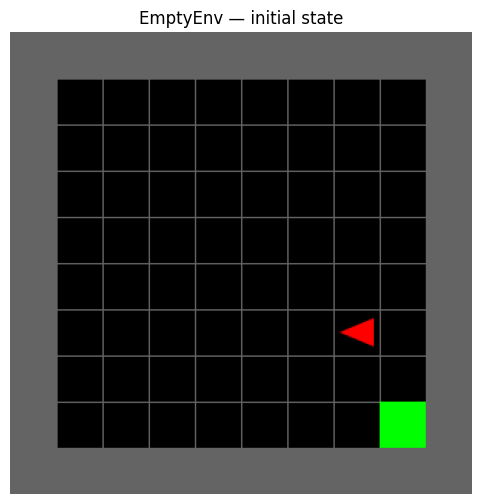

In [ ]:
# Sanity-check EmptyEnv: print the API surface, render the initial state,
# and save a short random-action rollout as mp4.
empty_env = EmptyEnv(max_steps=100)
obs, _ = empty_env.reset(seed=0)

print("=== EmptyEnv ===")
print(f"Grid size:        {empty_env.width} x {empty_env.height}")
print(f"Action space:     {empty_env.action_space}")
print(f"Number of actions: {empty_env.action_space.n}")
print(f"Agent position:   {empty_env.agent_pos}")
print(f"Agent direction:  {empty_env.agent_dir}")
print(f"Goal position:    {empty_env.goal_pos}")

plt.imshow(empty_env.render())
plt.title("EmptyEnv — initial state")
plt.axis("off")
plt.show()


In [ ]:
video_file = video_path("EmptyEnv_random.mp4")
steps, total_reward = random_rollout_video(empty_env, video_file, max_steps=100, seed=1)
print(f"Random rollout: steps={steps}, total_reward={total_reward:.2f}")
embed_mp4(video_file)


Random rollout: steps=100, total_reward=0.00


# Environment 2: KeyDoorLavaEnv

**Task.** Pick up the key in the **left room**, open the locked door, cross the lava through a
safe gap, and reach the goal in the **right room**.

| Property | Value |
|----------|-------|
| **Geometry** | |
| Grid size | `10×10` (1-cell outer wall + `8×8` walkable interior) |
| Partition wall | Vertical wall at column 4 — splits the interior into a **left room** (cols 1–3) and a **right room** (cols 5–8) |
| Lava column | Vertical lava at column 7 in the **right room** |
| Safe gaps | Rows 4 and 5 of the lava column — the only safe crossings |
| **Start state (randomised per episode)** | |
| Agent | Random cell in the **left room** (never on the key); random direction in `{0, 1, 2, 3}` |
| Key | One key at a random cell in the **left room** |
| Door | Locked door at a random row of the partition wall |
| Goal | Top-right or bottom-right corner, chosen at random |
| **Termination & reward** | |
| Lava contact | Episode ends immediately, reward `0` |
| Actions | All 7 MiniGrid actions |
| Reward | Sparse: `+1` on goal, `0` otherwise |

**Action subset.** Pick the subset your policy uses (`pickup` and `toggle` matter here, unlike
`EmptyEnv`) and keep it fixed for the run.

**Helper methods / attributes** (use these for state representation and reward shaping):
`env.is_carrying_key()`, `env.is_door_open()`, `env.has_crossed_lava()`, `env.is_on_lava()`,
`env.current_key_pos()` (returns `None` while carried); plus the attributes `env.agent_pos`,
`env.agent_dir`, `env.door_pos`, `env.goal_pos`, `env.partition_col`, `env.lava_col`,
`env.lava_gap_rows`, `env.lava_positions`.

> ⚠️ **Edit policy (KeyDoorLavaEnv).** You may:
> 1. Override `max_steps` at instantiation.
> 2. Scale the goal reward in `step()` (line marked `# you may scale this value`).
> 3. Add reward shaping inside the `# TODO (student): reward shaping` hooks in `__init__` /
>    `reset` / `step`: up to **two** event-based bonuses (e.g. on opening the door), plus an
>    optional small step penalty (which does **not** count toward the two).
>
> ❌ **Not allowed:** changing any other constructor default; any **distance-based** shaping
> (distance to goal/key/door/gap, tracked minimums) — these trivialise the task; any other code
> edits in the class.
>
> A bonus that looks helpful can quietly bias the policy — think about what each event encourages
> *and* what it might unintentionally encourage.

### Quick Test

=== KeyDoorLavaEnv ===
Grid size:               10 x 10
Action space:            Discrete(7)
Number of actions:       7
Agent position:          (1, 1)
Agent direction:         0
Partition column:        x=4
Key position:            (2, 5)
Door position:           (4, 7)
Lava column:             x=7
Lava gap rows:           y=[4, 5]
Lava cells:              [(7, 1), (7, 2), (7, 3), (7, 6), (7, 7), (7, 8)]
Goal position:           (8, 1)
is_carrying_key:         False
is_door_open:            False
has_crossed_lava:        False


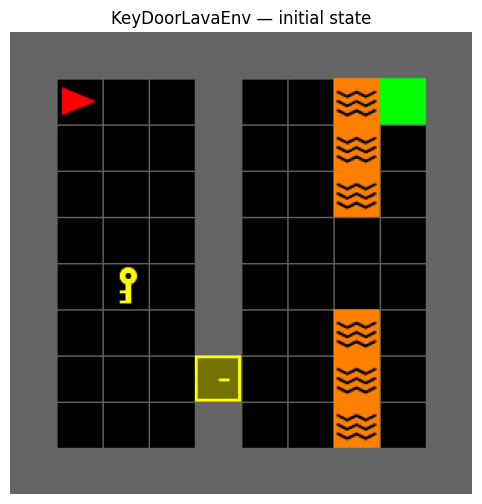

In [ ]:
# Sanity-check KeyDoorLavaEnv: print the API surface and helper-method outputs,
# render the initial state, and save a short random-action rollout as mp4.
keydoor_lava_env = KeyDoorLavaEnv(max_steps=100)
obs, _ = keydoor_lava_env.reset(seed=0)
print("=== KeyDoorLavaEnv ===")
print(f"Grid size:               {keydoor_lava_env.width} x {keydoor_lava_env.height}")
print(f"Action space:            {keydoor_lava_env.action_space}")
print(f"Number of actions:       {keydoor_lava_env.action_space.n}")
print(f"Agent position:          {keydoor_lava_env.agent_pos}")
print(f"Agent direction:         {keydoor_lava_env.agent_dir}")
print(f"Partition column:        x={keydoor_lava_env.partition_col}")
print(f"Key position:            {keydoor_lava_env.current_key_pos()}")
print(f"Door position:           {keydoor_lava_env.door_pos}")
print(f"Lava column:             x={keydoor_lava_env.lava_col}")
print(f"Lava gap rows:           y={keydoor_lava_env.lava_gap_rows}")
print(f"Lava cells:              {keydoor_lava_env.lava_positions}")
print(f"Goal position:           {keydoor_lava_env.goal_pos}")
print(f"is_carrying_key:         {keydoor_lava_env.is_carrying_key()}")
print(f"is_door_open:            {keydoor_lava_env.is_door_open()}")
print(f"has_crossed_lava:        {keydoor_lava_env.has_crossed_lava()}")

plt.imshow(keydoor_lava_env.render())
plt.title("KeyDoorLavaEnv — initial state")
plt.axis("off")
plt.show()


In [ ]:
video_file = video_path("KeyDoorLavaEnv_random.mp4")
steps, total_reward = random_rollout_video(keydoor_lava_env, video_file, max_steps=100, seed=1)
print(f"Random rollout: steps={steps}, total_reward={total_reward:.2f}")
embed_mp4(video_file)


Random rollout: steps=100, total_reward=0.00


# Your Code Below

Everything below this divider is yours to fill in. Add as many cells as you need, choose your own
structure, and make sure every deliverable required by the spec is clearly identifiable.